## 1. Install and Import Required Libraries

In [189]:
!pip install -q langchain langchain-community langchain-groq langchain-text-splitters
!pip install -q faiss-cpu sentence-transformers pdfplumber
!pip install -q pandas numpy groq tiktoken
!pip install -q langchain-huggingface

print("All packages installed")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
All packages installed


# Insurance Policy RAG System with LangChain

This notebook implements a RAG system for insurance policy documents using LangChain.

## Features:
- PDF extraction with metadata
- Semantic text splitting
- FAISS vector store
- Cross-encoder reranking
- Conversational agent with memory
- Source citations

In [190]:
import subprocess, sys

pkgs = [
    'langchain==0.2.16',
    'langchain-core==0.2.38',
    'langchain-community==0.2.16',
    'langchain-groq==0.1.9',
    'langchain-text-splitters==0.2.4',
    'langchain-huggingface==0.0.3',
    'faiss-cpu',
    'sentence-transformers',
    'pdfplumber',
    'pandas', 'numpy', 'groq', 'tiktoken'
]
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)

import numpy as np
import pandas as pd
import ast
import pdfplumber
from pathlib import Path
from operator import itemgetter
import json
import re
import textwrap
from typing import List

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.documents import Document

from langchain.chains import create_retrieval_chain, create_history_aware_retriever
from langchain.chains.combine_documents import create_stuff_documents_chain

from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_groq import ChatGroq

from sentence_transformers import SentenceTransformer, CrossEncoder

print("Libraries imported successfully")

Libraries imported successfully



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [191]:
# Set paths
input_path = '/Users/kandarp.joshi/Library/CloudStorage/OneDrive-ServiceNow/Prd/Prd/UpGrad/C6/M12/'
pdf_path = '/Users/kandarp.joshi/Library/CloudStorage/OneDrive-ServiceNow/Prd/Prd/UpGrad/C6/M12/Principal-Sample-Life-Insurance-Policy.pdf'

In [192]:
with pdfplumber.open(pdf_path) as pdf:
    single_page = pdf.pages[4]
    text = single_page.extract_text()
    tables = single_page.extract_tables()
    print(text)

PRINCIPAL LIFE INSURANCE COMPANY
(called The Principal in this Group Policy)
Des Moines, Iowa 50392-0002
This group insurance policy is issued to:
RHODE ISLAND JOHN DOE
(called the Policyholder in this Group Policy)
The Date of Issue is November 1, 2007.
In return for the Policyholder's application and payment of all premiums when due, The Principal
agrees to provide:
MEMBER LIFE INSURANCE
MEMBER ACCIDENTAL DEATH AND DISMEMBERMENT INSURANCE
DEPENDENT LIFE INSURANCE
subject to the terms and conditions described in this Group Policy.
GROUP POLICY NO. GL S655
RENEWABLE TERM - NON-PARTICIPATING
CONTRACT STATE OF ISSUE: RHODE ISLAND
This policy has been updated effective January 1, 2014
GC 6000 TITLE PAGE


In [193]:
def check_bboxes(word, table_bbox):
    l = word['x0'], word['top'], word['x1'], word['bottom']
    r = table_bbox
    return l[0] > r[0] and l[1] > r[1] and l[2] < r[2] and l[3] < r[3]

In [194]:
def extract_text_from_pdf(pdf_path):
    p = 0
    full_text = []

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_no = f"Page {p+1}"
            text = page.extract_text()

            tables = page.find_tables()
            table_bboxes = [i.bbox for i in tables]
            tables = [{'table': i.extract(), 'top': i.bbox[1]} for i in tables]
            non_table_words = [word for word in page.extract_words() if not any(
                [check_bboxes(word, table_bbox) for table_bbox in table_bboxes])]
            lines = []

            for cluster in pdfplumber.utils.cluster_objects(non_table_words + tables, itemgetter('top'), tolerance=5):
                if 'text' in cluster[0]:
                    try:
                        lines.append(' '.join([i['text'] for i in cluster]))
                    except KeyError:
                        pass
                elif 'table' in cluster[0]:
                    lines.append(json.dumps(cluster[0]['table']))

            full_text.append([page_no, " ".join(lines)])
            p +=1

    return full_text

In [195]:
# Define the directory containing the PDF files
pdf_directory = Path(input_path)

# Initialize an empty list to store the extracted texts and document names
data = []

# Loop through all files in the directory
for pdf_path in pdf_directory.glob("*.pdf"):

    # Process the PDF file
    print(f"...Processing {pdf_path.name}")

    # Call the function to extract the text from the PDF
    extracted_text = extract_text_from_pdf(pdf_path)

    # Convert the extracted list to a PDF, and add a column to store document names
    extracted_text_df = pd.DataFrame(extracted_text, columns=['Page No.', 'Page_Text'])
    extracted_text_df['Document Name'] = pdf_path.name

    # Append the extracted text and document name to the list
    data.append(extracted_text_df)

    # Print a message to indicate progress
    print(f"Finished processing {pdf_path.name}")

# Print a message to indicate all PDFs have been processed
print("All PDFs have been processed.")

...Processing Principal-Sample-Life-Insurance-Policy.pdf
Finished processing Principal-Sample-Life-Insurance-Policy.pdf
...Processing Helpmate_AI_Report_KandarpJoshi.pdf
Finished processing Helpmate_AI_Report_KandarpJoshi.pdf
...Processing Helpmate_AI_Output_KandarpJoshi.pdf
Finished processing Helpmate_AI_Output_KandarpJoshi.pdf
All PDFs have been processed.


In [196]:
insurance_pdfs_data = pd.concat(data, ignore_index=True)
insurance_pdfs_data

,Page No.,Page_Text,Document Name
0,Page 1,DOROTHEA GLAUSE S655 RHODE ISLAND JOHN DOE 01/...,Principal-Sample-Life-Insurance-Policy.pdf
1,Page 2,This page left blank intentionally,Principal-Sample-Life-Insurance-Policy.pdf
2,Page 3,POLICY RIDER GROUP INSURANCE POLICY NO: S655 C...,Principal-Sample-Life-Insurance-Policy.pdf
3,Page 4,This page left blank intentionally,Principal-Sample-Life-Insurance-Policy.pdf
4,Page 5,PRINCIPAL LIFE INSURANCE COMPANY (called The P...,Principal-Sample-Life-Insurance-Policy.pdf
...,...,...,...
73,Page 10,"o User-centric design (citations, clarity, err...",Helpmate_AI_Report_KandarpJoshi.pdf
74,Page 1,Helpmate AI Project - Insurance RESULTS: Query...,Helpmate_AI_Output_KandarpJoshi.pdf
75,Page 2,Query 2: Coverage During Disability will be ef...,Helpmate_AI_Output_KandarpJoshi.pdf
76,Page 3,Query 3: What are the Policy guidelines for Lo...,Helpmate_AI_Output_KandarpJoshi.pdf


In [197]:
# Function 1: Fixed-size chunking with overlap
def chunk_text_with_overlap(text, chunk_size=400, overlap=50):

    words = text.split()
    chunks = []
    
    for i in range(0, len(words), chunk_size - overlap):
        chunk = ' '.join(words[i:i + chunk_size])
        if chunk.strip():  # Only add non-empty chunks
            chunks.append(chunk)
    
    return chunks


# Function 2: Section-based chunking for insurance documents
def chunk_by_sections(text):
    
    # Pattern to match section headers
    section_pattern = r'(?:^|\n)(?:\d+\.|[A-Z]\.|Section \d+:|PART [A-Z]|ANNEXURE|Clause \d+)'
    
    sections = re.split(section_pattern, text)
    sections = [s.strip() for s in sections if s.strip() and len(s.strip()) > 20]
    
    return sections


# Function 3: Hybrid chunking strategy (RECOMMENDED)
def hybrid_chunking(text, page_no, policy_name, chunk_size=400, overlap=50):
    
    # First, try to split by sections
    sections = chunk_by_sections(text)
    
    # If no sections found, treat entire text as one section
    if not sections:
        sections = [text]
    
    chunks_with_metadata = []
    
    for section_idx, section in enumerate(sections):
        word_count = len(section.split())
        
        # If section is too large, split it further
        if word_count > chunk_size:
            sub_chunks = chunk_text_with_overlap(section, chunk_size, overlap)
            
            for sub_idx, sub_chunk in enumerate(sub_chunks):
                chunk_data = {
                    'Chunk_Text': sub_chunk,
                    'Page_No': page_no,
                    'Policy_Name': policy_name,
                    'Chunk_ID': f"P{page_no}_S{section_idx}_C{sub_idx}",
                    'Word_Count': len(sub_chunk.split()),
                    'Chunk_Type': 'section_split'
                }
                chunks_with_metadata.append(chunk_data)
        else:
            # Keep section as is
            chunk_data = {
                'Chunk_Text': section,
                'Page_No': page_no,
                'Policy_Name': policy_name,
                'Chunk_ID': f"P{page_no}_S{section_idx}",
                'Word_Count': word_count,
                'Chunk_Type': 'full_section'
            }
            chunks_with_metadata.append(chunk_data)
    
    return chunks_with_metadata


# Function 4: Apply chunking to entire dataframe
def apply_hybrid_chunking_to_df(insurance_pdfs_data):
    
    all_chunks = []
    
    for idx, row in insurance_pdfs_data.iterrows():
        chunks = hybrid_chunking(
            text=row['Page_Text'],
            page_no=row['Page No.'],
            policy_name=row['Document Name'][:-4] if 'Document Name' in row else 'Unknown',
            chunk_size=400,
            overlap=50
        )
        all_chunks.extend(chunks)
    
    chunks_df = pd.DataFrame(all_chunks)
    
    print(f"Original pages: {len(insurance_pdfs_data)}")
    print(f"Total chunks created: {len(chunks_df)}")
    print(f"Average chunk size: {chunks_df['Word_Count'].mean():.1f} words")
    print(f"\nChunk type distribution:")
    print(chunks_df['Chunk_Type'].value_counts())
    
    return chunks_df

In [198]:
embedding_function = HuggingFaceEmbeddings(
    model_name="multi-qa-mpnet-base-dot-v1",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)

print("Embeddings initialized")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/multi-qa-mpnet-base-dot-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embeddings initialized


In [199]:
# Apply hybrid chunking to your insurance data
print("Applying hybrid chunking strategy...")
insurance_chunks_df = apply_hybrid_chunking_to_df(insurance_pdfs_data)

# Display sample chunks
print("\n" + "="*100)
print("Sample chunks:")
print("="*100)
display(insurance_chunks_df.head(3))

Applying hybrid chunking strategy...
Original pages: 78
Total chunks created: 86
Average chunk size: 207.3 words

Chunk type distribution:
Chunk_Type
full_section     70
section_split    16
Name: count, dtype: int64

Sample chunks:


,Chunk_Text,Page_No,Policy_Name,Chunk_ID,Word_Count,Chunk_Type
0,DOROTHEA GLAUSE S655 RHODE ISLAND JOHN DOE 01/...,Page 1,Principal-Sample-Life-Insurance-Policy,PPage 1_S0,30,full_section
1,This page left blank intentionally,Page 2,Principal-Sample-Life-Insurance-Policy,PPage 2_S0,5,full_section
2,POLICY RIDER GROUP INSURANCE POLICY NO: S655 C...,Page 3,Principal-Sample-Life-Insurance-Policy,PPage 3_S0,230,full_section


In [200]:
# First, check what columns you have
print("Available columns in insurance_pdfs_data:")
print(insurance_chunks_df.columns.tolist())

Available columns in insurance_pdfs_data:
['Chunk_Text', 'Page_No', 'Policy_Name', 'Chunk_ID', 'Word_Count', 'Chunk_Type']


In [201]:
insurance_pdfs_data.head(5)

,Page No.,Page_Text,Document Name
0,Page 1,DOROTHEA GLAUSE S655 RHODE ISLAND JOHN DOE 01/...,Principal-Sample-Life-Insurance-Policy.pdf
1,Page 2,This page left blank intentionally,Principal-Sample-Life-Insurance-Policy.pdf
2,Page 3,POLICY RIDER GROUP INSURANCE POLICY NO: S655 C...,Principal-Sample-Life-Insurance-Policy.pdf
3,Page 4,This page left blank intentionally,Principal-Sample-Life-Insurance-Policy.pdf
4,Page 5,PRINCIPAL LIFE INSURANCE COMPANY (called The P...,Principal-Sample-Life-Insurance-Policy.pdf


In [202]:
# Retain only the rows with a text length of at least 10

insurance_chunks_df = insurance_chunks_df.loc[insurance_chunks_df['Word_Count'] >= 10]
# Sort by text_length from high to low
insurance_chunks_df = insurance_chunks_df.sort_values(by='Word_Count', ascending=False)
insurance_chunks_df

,Chunk_Text,Page_No,Policy_Name,Chunk_ID,Word_Count,Chunk_Type
67,Section D - Claim Procedures Article 1 - Notic...,Page 61,Principal-Sample-Life-Insurance-Policy,PPage 61_S0_C0,400,section_split
55,The Principal may require that a ADL Disabled ...,Page 50,Principal-Sample-Life-Insurance-Policy,PPage 50_S0_C0,400,section_split
36,a . In no event will Dependent Life Insurance ...,Page 33,Principal-Sample-Life-Insurance-Policy,PPage 33_S0_C0,400,section_split
34,(1) marriage or establishment of a Civil Union...,Page 32,Principal-Sample-Life-Insurance-Policy,PPage 32_S0_C0,400,section_split
32,Scheduled Benefit in force for the Member befo...,Page 31,Principal-Sample-Life-Insurance-Policy,PPage 31_S0_C0,400,section_split
...,...,...,...,...,...,...
82,Helpmate AI Project - Insurance RESULTS: Query...,Page 1,Helpmate_AI_Output_KandarpJoshi,PPage 1_S0,20,full_section
83,Query 2: Coverage During Disability will be ef...,Page 2,Helpmate_AI_Output_KandarpJoshi,PPage 2_S0,20,full_section
76,Query 2: Coverage During Disability will be ef...,Page 5,Helpmate_AI_Report_KandarpJoshi,PPage 5_S0,18,full_section
84,Query 3: What are the Policy guidelines for Lo...,Page 3,Helpmate_AI_Output_KandarpJoshi,PPage 3_S0,17,full_section


In [203]:
# Store the metadata for each page in a separate column

#insurance_pdfs_data.loc[:, 'Metadata'] = insurance_pdfs_data.apply(lambda x: {'Policy_Name': x['Document Name'][:-4], 'Page_No.': x['Page No.']}, axis=1)
#insurance_pdfs_data.head(5)

insurance_chunks_df.loc[:, 'Metadata'] = insurance_chunks_df.apply(lambda x: {'Policy_Name': x['Policy_Name'][:-4], 'Page_No.': x['Page_No']}, axis=1)
insurance_chunks_df.head(5)

,Chunk_Text,Page_No,Policy_Name,Chunk_ID,Word_Count,Chunk_Type,Metadata
67,Section D - Claim Procedures Article 1 - Notic...,Page 61,Principal-Sample-Life-Insurance-Policy,PPage 61_S0_C0,400,section_split,{'Policy_Name': 'Principal-Sample-Life-Insuran...
55,The Principal may require that a ADL Disabled ...,Page 50,Principal-Sample-Life-Insurance-Policy,PPage 50_S0_C0,400,section_split,{'Policy_Name': 'Principal-Sample-Life-Insuran...
36,a . In no event will Dependent Life Insurance ...,Page 33,Principal-Sample-Life-Insurance-Policy,PPage 33_S0_C0,400,section_split,{'Policy_Name': 'Principal-Sample-Life-Insuran...
34,(1) marriage or establishment of a Civil Union...,Page 32,Principal-Sample-Life-Insurance-Policy,PPage 32_S0_C0,400,section_split,{'Policy_Name': 'Principal-Sample-Life-Insuran...
32,Scheduled Benefit in force for the Member befo...,Page 31,Principal-Sample-Life-Insurance-Policy,PPage 31_S0_C0,400,section_split,{'Policy_Name': 'Principal-Sample-Life-Insuran...


Above steps concludes the chunking aspect, as we can see that mostly the pages contain few hundred words, maximum going upto 462. So, we don't need to chunk the documents further; we can perform the embeddings on individual pages. This strategy makes sense for 2 reasons:
1. The way insurance documents are generally structured, you will not have a lot of extraneous information in a page, and all the text pieces in that page will likely be interrelated.
2. We want to have larger chunk sizes to be able to pass appropriate context to the LLM during the generation layer.

## STEP 2. Embedding via FAISS

In [204]:
# Create metadata for each chunk
insurance_chunks_df['Metadata'] = insurance_chunks_df.apply(
    lambda x: {
        'Policy_Name': x['Policy_Name'],
        'Page_No': str(x['Page_No']),
        'Chunk_ID': x['Chunk_ID'],
        'Word_Count': x['Word_Count'],
        'Chunk_Type': x['Chunk_Type']
    }, 
    axis=1
)

# Prepare data for ChromaDB
documents_list = insurance_chunks_df['Chunk_Text'].tolist()
metadata_list = insurance_chunks_df['Metadata'].tolist()
ids_list = insurance_chunks_df['Chunk_ID'].tolist()

print(f"\nPrepared {len(documents_list)} chunks for embedding")
print(f"Sample metadata: {metadata_list[0]}")


Prepared 80 chunks for embedding
Sample metadata: {'Policy_Name': 'Principal-Sample-Life-Insurance-Policy', 'Page_No': 'Page 61', 'Chunk_ID': 'PPage 61_S0_C0', 'Word_Count': 400, 'Chunk_Type': 'section_split'}


In [205]:
# (Replaced by FAISS — see vector store setup below)
print("ChromaDB removed — using FAISS vector store (LangChain native)")


ChromaDB removed — using FAISS vector store (LangChain native)


In [206]:
# Build FAISS vector store
documents = [
    Document(
        page_content=row["Chunk_Text"],
        metadata={
            "Policy_Name": row["Policy_Name"],
            "Page_No":     row["Page_No"],
            "Chunk_ID":    row["Chunk_ID"],
            "Chunk_Type":  row["Chunk_Type"],
        },
    )
    for _, row in insurance_chunks_df.iterrows()
]

print(f"Created {len(documents)} document objects")

vectorstore = FAISS.from_documents(documents, embedding_function)
print(f"FAISS vector store built: {vectorstore.index.ntotal} vectors, dim={vectorstore.index.d}")

vectorstore.save_local(input_path + "faiss_index")
print(f"Saved to: {input_path}faiss_index")

Created 80 document objects
FAISS vector store built: 80 vectors, dim=768
Saved to: /Users/kandarp.joshi/Library/CloudStorage/OneDrive-ServiceNow/Prd/Prd/UpGrad/C6/M12/faiss_index


In [207]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5},
)

print("FAISS retriever ready")

FAISS retriever ready


In [208]:
# Documents are already in the FAISS index — no manual batch insert needed.
print(f"Vector store contains {vectorstore.index.ntotal} indexed chunks.")


Vector store contains 80 indexed chunks.


In [209]:
# Test FAISS retrieval
test_query = "What are the exclusions in this policy?"

print(f"Test Query: {test_query}")
print("=" * 100)

docs = retriever.invoke(test_query)
print(f"Retrieved {len(docs)} documents\n")

for i, doc in enumerate(docs, 1):
    print(f"[{i}] Policy: {doc.metadata.get('Policy_Name')} | Page: {doc.metadata.get('Page_No')}")
    print(f"    {doc.page_content[:200]}...")
    print()


Test Query: What are the exclusions in this policy?
Retrieved 5 documents

[1] Policy: Principal-Sample-Life-Insurance-Policy | Page: Page 9
    P ART I - DEFINITIONS When used in this Group Policy the terms listed below will mean: Active Work; Actively at Work A Member will be considered Actively at Work if he or she is able and available for...

[2] Policy: Principal-Sample-Life-Insurance-Policy | Page: Page 37
    b. a business assignment; or c. full-time student status, provided the Member or Dependent is either: (1) enrolled and attending an accredited school in a foreign country; or (2) is participating in a...

[3] Policy: Principal-Sample-Life-Insurance-Policy | Page: Page 12
    An institution that is licensed as a Hospital by the proper authority of the state in which it is l ocated, but not including any institution, or part thereof, that is used primarily as a clinic, Skil...

[4] Policy: Principal-Sample-Life-Insurance-Policy | Page: Page 7
    Section A – Eligibility Memb

In [210]:
# Placeholder - function defined after RAG chain creation
pass

In [211]:
# Placeholder - test queries defined after function creation
pass

In [212]:
# Convert the page text and metadata from your dataframe to lists to be able to pass it to chroma

#documents_list = insurance_pdfs_data["Page_Text"].tolist()
#metadata_list = insurance_pdfs_data['Metadata'].tolist()

In [213]:
# Documents are stored in FAISS — no manual insert needed.
# The vectorstore was built in one step via FAISS.from_documents()
print(f"FAISS index contains {vectorstore.index.ntotal} vectors.")


FAISS index contains 80 vectors.


In [214]:
# FAISS vector store summary
print(f"Total vectors : {vectorstore.index.ntotal}")
print(f"Embedding dim : {vectorstore.index.d}")

sample = retriever.invoke("insurance coverage types")
print(f"\nSample retrieval — top-3 for 'insurance coverage types':")
for doc in sample[:3]:
    print(f"  [{doc.metadata.get('Policy_Name')} | Page {doc.metadata.get('Page_No')}] {doc.page_content[:100]}...")


Total vectors : 80
Embedding dim : 768

Sample retrieval — top-3 for 'insurance coverage types':
  [Principal-Sample-Life-Insurance-Policy | Page Page 3] POLICY RIDER GROUP INSURANCE POLICY NO: S655 COVERAGE: Life EMPLOYER: RHODE ISLAND JOHN DOE Effectiv...
  [Principal-Sample-Life-Insurance-Policy | Page Page 55] Exposure Exposure to the elements will be presumed to be an injury if: a. such exposure is due to an...
  [Principal-Sample-Life-Insurance-Policy | Page Page 56] If a Member sustains an injury, and as a result of such injury, one or more of the covered losses li...


## STEP 3. Build Conversational Agent with LangChain

Create a conversational agent with:
1. LangChain framework for conversation management
2. Chat history for context-aware responses
3. Policy information retrieval from FAISS
4. Source citations
5. Follow-up question handling

In [ ]:
import os

# Set your Groq API key here
# Get your key from: https://console.groq.com/keys
os.environ["GROQ_API_KEY"] = ""

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.3,
    max_tokens=2048
)

print("LLM initialized")

LLM initialized


In [216]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5},
)

print("FAISS retriever ready")

FAISS retriever ready


In [217]:
contextualize_q_system_prompt = """Given a chat history and the latest user question \
which might reference context in the chat history, formulate a standalone question \
which can be understood without the chat history. Do NOT answer the question, \
just reformulate it if needed and otherwise return it as is."""

contextualize_q_prompt = ChatPromptTemplate.from_messages([
    ("system", contextualize_q_system_prompt),
    MessagesPlaceholder("chat_history"),
    ("human", "{input}"),
])

history_aware_retriever = create_history_aware_retriever(
    llm, retriever, contextualize_q_prompt
)

print("History-aware retriever created")

History-aware retriever created


In [218]:
qa_system_prompt = """You are an expert insurance policy assistant helping users understand their insurance policies. \
Use the following pieces of retrieved context to answer the question accurately and comprehensively.

IMPORTANT INSTRUCTIONS:
1. Answer based ONLY on the provided context from the policy documents
2. If the answer is not in the context, say "I don't have enough information in the policy documents to answer that question"
3. Be specific and cite relevant policy sections when possible
4. Use clear, professional language
5. If there are multiple relevant points, organize them with bullet points
6. Always mention the source document and page number when providing information

Context from policy documents:
{context}

Answer the user's question clearly and professionally."""

qa_prompt = ChatPromptTemplate.from_messages([
    ("system", qa_system_prompt),
    MessagesPlaceholder("chat_history"),
    ("human", "{input}"),
])

print("QA prompt template created")

QA prompt template created


In [219]:
question_answer_chain = create_stuff_documents_chain(llm, qa_prompt)

rag_chain = create_retrieval_chain(history_aware_retriever, question_answer_chain)

print("RAG chain created")

RAG chain created


In [220]:
def ask_insurance_question(question: str, chat_history: list = None):
    """
    Ask a question about insurance policies using the RAG chain
    
    Args:
        question: The user's question
        chat_history: Optional list of previous messages
    
    Returns:
        dict with 'answer' and 'context' keys
    """
    if chat_history is None:
        chat_history = []
    
    result = rag_chain.invoke({
        "input": question,
        "chat_history": chat_history
    })
    
    print(f"Question: {question}")
    print("=" * 100)
    print(f"\nAnswer:\n{result['answer']}")
    print("\n" + "-" * 100)
    
    print("\nSource Documents:")
    for i, doc in enumerate(result.get('context', []), 1):
        print(f"\n[{i}] {doc.metadata.get('Policy_Name')} | Page {doc.metadata.get('Page_No')}")
        print(f"    {doc.page_content[:150]}...")
    
    return result

print("Function defined")

Function defined


In [221]:
test_queries = [
    "What is covered under this insurance policy?",
    "What are the exclusions in this policy?",
    "What are the Policy guidelines for Loss of Use or Paralysis?",
]

print("TESTING RAG SYSTEM")
print("=" * 100)

for query in test_queries[:3]:
    result = ask_insurance_question(query)
    print("\n" + "=" * 100 + "\n")

TESTING RAG SYSTEM


AuthenticationError: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}

In [ ]:
import time

# Rate limiting configuration
DELAY_BETWEEN_REQUESTS = 15

def evaluate_response_quality(response_text: str, expected_keywords: list, question: str) -> dict:
    """Multi-dimensional quality evaluation of a single RAG response."""
    response_lower = response_text.lower()
    
    # Keyword coverage
    found = [kw for kw in expected_keywords if kw.lower() in response_lower]
    keyword_score = len(found) / len(expected_keywords)
    
    # Response length (target: 50-300 words)
    wc = len(response_text.split())
    if wc < 50:
        length_score = wc / 50
    elif wc > 300:
        length_score = max(0.3, 300 / wc)
    else:
        length_score = 1.0
    
    # Source citation
    citation_indicators = ["page", "policy", "section", "part", "article", "clause"]
    citation_score = 1.0 if any(ind in response_lower for ind in citation_indicators) else 0.0
    
    # Non-refusal
    refusal_phrases = ["i don't have", "i cannot", "not available", "no information found"]
    refusal_score = 0.0 if any(p in response_lower for p in refusal_phrases) else 1.0
    
    combined = (
        keyword_score * 0.40
        + length_score  * 0.20
        + citation_score * 0.25
        + refusal_score * 0.15
    )
    
    return {
        "keyword_score": keyword_score,
        "length_score": length_score,
        "citation_score": citation_score,
        "refusal_score": refusal_score,
        "combined_score": combined,
        "found_keywords": found,
        "word_count": wc,
    }


extended_test_suite = [
    {"question": "What types of insurance are provided under this policy?",
     "expected_keywords": ["Member Life Insurance", "Accidental Death", "Dismemberment", "Dependent"],
     "category": "Coverage"},
    {"question": "How do I file a claim?",
     "expected_keywords": ["written notice", "Principal", "claim"],
     "category": "Claims"},
    {"question": "What is the grace period for premium payment?",
     "expected_keywords": ["grace period", "premium", "days"],
     "category": "Premiums"},
    {"question": "Who is eligible for coverage?",
     "expected_keywords": ["Member", "eligible", "Active Work"],
     "category": "Eligibility"},
    {"question": "Can coverage be terminated?",
     "expected_keywords": ["termination", "coverage", "policy"],
     "category": "Termination"},
    {"question": "What is covered under disability benefits?",
     "expected_keywords": ["disability", "benefit", "loss"],
     "category": "Disability"},
    {"question": "What exclusions apply to accidental death coverage?",
     "expected_keywords": ["exclusion", "accidental", "death"],
     "category": "Exclusions"},
]

agent.reset_conversation()
enhanced_results = []

print("MULTI-METRIC EVALUATION (with rate limiting)")
print("=" * 100)

for i, test in enumerate(extended_test_suite, 1):
    t0 = time.time()
    
    try:
        resp = agent.ask(test["question"], verbose=False)
        elapsed = round(time.time() - t0, 2)
        
        metrics = evaluate_response_quality(resp["answer"], test["expected_keywords"], test["question"])
        metrics.update({
            "response_time_sec": elapsed,
            "num_sources": len(resp.get("context", [])),
            "question": test["question"],
            "category": test["category"],
        })
        enhanced_results.append(metrics)
        
        print(
            f"[{i}] {test['category']:<12} | "
            f"Keyword {metrics['keyword_score']:.0%} | "
            f"Citation {metrics['citation_score']:.0%} | "
            f"Combined {metrics['combined_score']:.0%} | "
            f"{elapsed}s"
        )
        
        if i < len(extended_test_suite):
            print(f"    Waiting {DELAY_BETWEEN_REQUESTS}s before next request...")
            time.sleep(DELAY_BETWEEN_REQUESTS)
            
    except Exception as e:
        print(f"[{i}] {test['category']:<12} | ERROR: {str(e)}")
        if "rate_limit" in str(e).lower():
            print(f"    Rate limit hit. Consider increasing DELAY_BETWEEN_REQUESTS or waiting before continuing.")
            break

if enhanced_results:
    metrics_df = pd.DataFrame(enhanced_results)
    
    print("\n" + "=" * 100)
    print("EVALUATION SUMMARY")
    print("=" * 100)
    print(f"\n{'Category':<15} {'Keyword':>10} {'Citation':>10} {'Length':>10} {'Combined':>10} {'Time(s)':>8}")
    print("-" * 70)
    for _, row in metrics_df.iterrows():
        print(
            f"{row['category']:<15} {row['keyword_score']:>10.1%} {row['citation_score']:>10.1%} "
            f"{row['length_score']:>10.1%} {row['combined_score']:>10.1%} {row['response_time_sec']:>8.2f}"
        )
    print("-" * 70)
    print(
        f"{'AVERAGE':<15} {metrics_df['keyword_score'].mean():>10.1%} "
        f"{metrics_df['citation_score'].mean():>10.1%} "
        f"{metrics_df['length_score'].mean():>10.1%} "
        f"{metrics_df['combined_score'].mean():>10.1%} "
        f"{metrics_df['response_time_sec'].mean():>8.2f}"
    )

✓ Conversation history cleared
MULTI-METRIC EVALUATION (with rate limiting)
[1] Coverage     | Keyword 100% | Citation 100% | Combined 100% | 1.73s
    Waiting 15s before next request...
[2] Claims       | Keyword 67% | Citation 100% | Combined 87% | 12.35s
    Waiting 15s before next request...
[3] Premiums     | Keyword 100% | Citation 100% | Combined 100% | 33.8s
    Waiting 15s before next request...
[4] Eligibility  | Keyword 67% | Citation 100% | Combined 87% | 15.95s
    Waiting 15s before next request...
[5] Termination  | Keyword 100% | Citation 100% | Combined 90% | 24.49s
    Waiting 15s before next request...
[6] Disability   | Keyword 100% | Citation 100% | Combined 94% | 54.01s
    Waiting 15s before next request...
[7] Exclusions   | Keyword 100% | Citation 100% | Combined 90% | 68.42s

EVALUATION SUMMARY

Category           Keyword   Citation     Length   Combined  Time(s)
----------------------------------------------------------------------
Coverage            100.0% 

In [ ]:
# Create a conversational agent class to manage chat sessions
class InsurancePolicyAgent:
    """Conversational agent for insurance policy queries with memory"""
    
    def __init__(self, rag_chain):
        self.rag_chain = rag_chain
        self.chat_history = []
        self.conversation_log = []
    
    def ask(self, question: str, verbose: bool = True) -> dict:
        """
        Ask a question to the agent
        
        Args:
            question: User's question
            verbose: Whether to print formatted output
            
        Returns:
            Dictionary with answer, sources, and metadata
        """
        # Invoke the RAG chain
        response = self.rag_chain.invoke({
            "input": question,
            "chat_history": self.chat_history
        })
        
        # Update chat history
        self.chat_history.extend([
            HumanMessage(content=question),
            AIMessage(content=response["answer"])
        ])
        
        # Log the conversation
        self.conversation_log.append({
            "question": question,
            "answer": response["answer"],
            "sources": response.get("context", [])
        })
        
        if verbose:
            self._print_response(question, response)
        
        return response
    
    def _print_response(self, question: str, response: dict):
        """Pretty print the response"""
        print("\n" + "="*100)
        print(f"❓ QUESTION: {question}")
        print("="*100)
        print(f"\n💡 ANSWER:\n{response['answer']}")
        
        if response.get("context"):
            print("\n" + "-"*100)
            print("📚 SOURCES:")
            print("-"*100)
            for i, doc in enumerate(response["context"][:3], 1):
                metadata = doc.metadata
                print(f"\n[Source {i}]")
                print(f"  Policy: {metadata.get('Policy_Name', 'N/A')}")
                print(f"  Page: {metadata.get('Page_No', 'N/A')}")
                print(f"  Chunk ID: {metadata.get('Chunk_ID', 'N/A')}")
                print(f"  Preview: {doc.page_content[:150]}...")
        print("\n" + "="*100 + "\n")
    
    def reset_conversation(self):
        """Reset the chat history"""
        self.chat_history = []
        self.conversation_log = []
        print("✓ Conversation history cleared")
    
    def get_conversation_summary(self):
        """Get a summary of the conversation"""
        return {
            "total_questions": len(self.conversation_log),
            "conversation_log": self.conversation_log
        }

# Initialize the agent
agent = InsurancePolicyAgent(rag_chain)

print("✓ Conversational Agent initialized successfully!")
print("\nYou can now interact with the agent using:")
print("  agent.ask('Your question here')")
print("  agent.reset_conversation()  # To start a new conversation")
print("  agent.get_conversation_summary()  # To view conversation history")

✓ Conversational Agent initialized successfully!

You can now interact with the agent using:
  agent.ask('Your question here')
  agent.reset_conversation()  # To start a new conversation
  agent.get_conversation_summary()  # To view conversation history


## STEP 3.5 <font color = red> Advanced LangChain Enhancements </font>

The following enhancements build on the base RAG system to deliver higher accuracy,
better scalability, and richer conversational capabilities:

1. **Multi-Query Retriever** — generates multiple query variants for better recall
2. **Re-ranked Retriever** — fuses ChromaDB retrieval with cross-encoder re-ranking
3. **LangChain ReAct Agent with Tools** — tool-using agent for complex multi-step queries
4. **Streaming + Summary Memory Agent** — real-time output & auto-summarizes long conversations

In [ ]:
# ── Enhancement 1: Multi-Query Retriever ─────────────────────────────────────
# Generates 3 query variations to improve document recall from ChromaDB

from langchain.retrievers.multi_query import MultiQueryRetriever
import logging

# Suppress verbose output from multi-query retriever
logging.getLogger("langchain.retrievers.multi_query").setLevel(logging.ERROR)

multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever=retriever,
    llm=llm
)

print("✓ Multi-Query Retriever created")
print("  - Generates 3 query variants per user question")
print("  - Merges results for higher document recall")
print("  - Deduplicates retrieved chunks automatically")

# Quick test
test_docs = multi_query_retriever.invoke("What is covered under this policy?")
print(f"\nTest: retrieved {len(test_docs)} unique documents for a sample query")

✓ Multi-Query Retriever created
  - Generates 3 query variants per user question
  - Merges results for higher document recall
  - Deduplicates retrieved chunks automatically

Test: retrieved 13 unique documents for a sample query


In [ ]:
# ── Enhancement 2: LangChain-native Cross-Encoder Re-ranking ─────────────────
# Uses ContextualCompressionRetriever — no custom class needed!
#   Step 1: FAISS fetches top-20 candidates (high recall)
#   Step 2: CrossEncoderReranker scores & keeps top-5 (high precision)

cross_encoder_hf = HuggingFaceCrossEncoder(model_name="cross-encoder/ms-marco-MiniLM-L-6-v2")
compressor = CrossEncoderReranker(model=cross_encoder_hf, top_n=5)

base_retriever_wide = vectorstore.as_retriever(search_kwargs={"k": 20})

reranked_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=base_retriever_wide,
)

print("✓ Re-ranked Retriever created (LangChain native — ContextualCompressionRetriever)")
print("  Base  : FAISS top-20")
print("  Rerank: cross-encoder/ms-marco-MiniLM-L-6-v2")
print("  Output: top-5 most relevant chunks")


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Re-ranked Retriever created (LangChain native — ContextualCompressionRetriever)
  Base  : FAISS top-20
  Rerank: cross-encoder/ms-marco-MiniLM-L-6-v2
  Output: top-5 most relevant chunks


In [ ]:
# Build a second RAG chain that uses the re-ranked retriever
# This chain is more precise; use it when accuracy matters most.

history_aware_retriever_reranked = create_history_aware_retriever(
    llm, reranked_retriever, contextualize_q_prompt
)

question_answer_chain_reranked = create_stuff_documents_chain(llm, qa_prompt)

rag_chain_reranked = create_retrieval_chain(
    history_aware_retriever_reranked, question_answer_chain_reranked
)

# Initialise agent with re-ranked retriever
agent_reranked = InsurancePolicyAgent(rag_chain_reranked)

print("✓ Re-ranked RAG chain + agent ready")
print("  Chain: History-aware retriever → Cross-encoder re-ranking → LLM")

# Quick test
resp = agent_reranked.ask("What exclusions apply to accidental death coverage?", verbose=True)

✓ Re-ranked RAG chain + agent ready
  Chain: History-aware retriever → Cross-encoder re-ranking → LLM

❓ QUESTION: What exclusions apply to accidental death coverage?

💡 ANSWER:
Based on the provided policy documents, the following exclusions apply to accidental death coverage:

1. **Suicide**: There is no specific mention of suicide as an exclusion in the provided policy documents. However, it is generally a common exclusion in life insurance policies, and I would recommend reviewing the policy documents or contacting the insurance provider for clarification.
2. **War or Military Action**: There is no specific mention of war or military action as an exclusion in the provided policy documents.
3. **Self-Inflicted Injury**: There is no specific mention of self-inflicted injury as an exclusion in the provided policy documents.
4. **Intentional Acts**: There is no specific mention of intentional acts as an exclusion in the provided policy documents.
5. **Losses Resulting from Participatio

### Enhancement 3 — LangChain ReAct Agent with Tools

A proper tool-using agent gives the LLM the ability to *choose* how to retrieve
information rather than always using a single retriever.

| Tool | Purpose |
|------|---------|
| `search_policy_documents` | Direct semantic search for facts |
| `get_policy_summary` | Topic-focused summarisation |
| `compare_coverage_aspects` | Side-by-side comparison of two topics |

In [ ]:
from langchain.agents import AgentExecutor, create_react_agent
from langchain.tools import Tool
from langchain_core.prompts import PromptTemplate


# ── Tool 1: Semantic search ───────────────────────────────────────────────────
def search_policy_documents(query: str) -> str:
    """Search insurance policy documents and return the most relevant excerpts."""
    results = retriever.invoke(query)
    parts = []
    for i, (doc, meta) in enumerate(
        zip(results["documents"][0], results["metadatas"][0]), 1
    ):
        parts.append(
            f"[Source {i}] Policy: {meta.get('Policy_Name','N/A')}, "
            f"Page: {meta.get('Page_No','N/A')}\n{doc[:300]}"
        )
    return "\n\n".join(parts)


# ── Tool 2: Topic summary ─────────────────────────────────────────────────────
def get_policy_summary(topic: str) -> str:
    """Return a bullet-point summary for a specific insurance topic or section."""
    results = insurance_collection.query(
        query_texts=[f"summary overview {topic}"], n_results=3
    )
    docs = " ".join(results["documents"][0])
    prompt = (
        f"Summarise the key points about '{topic}' from this insurance policy "
        f"text in 3-5 concise bullet points:\n\n{docs[:1500]}"
    )
    return llm.invoke(prompt).content


# ── Tool 3: Coverage comparison ───────────────────────────────────────────────
def compare_coverage_aspects(aspects: str) -> str:
    """Compare two or more coverage aspects or sections side-by-side."""
    results = insurance_collection.query(query_texts=[aspects], n_results=6)
    excerpts = "\n\n".join(
        f"[Page {meta.get('Page_No','?')}] {doc[:250]}"
        for doc, meta in zip(results["documents"][0], results["metadatas"][0])
    )
    prompt = (
        f"Compare and explain the following aspects based on the policy excerpts: "
        f"{aspects}\n\n{excerpts}"
    )
    return llm.invoke(prompt).content


# ── Register tools ────────────────────────────────────────────────────────────
tools = [
    Tool(
        name="search_policy_documents",
        func=search_policy_documents,
        description=(
            "Search insurance policy documents for specific facts about coverage, "
            "exclusions, premiums, claims, or eligibility. Input: a clear search query."
        ),
    ),
    Tool(
        name="get_policy_summary",
        func=get_policy_summary,
        description=(
            "Get a concise bullet-point summary of a specific insurance topic such as "
            "'disability benefits', 'claim process', or 'grace period'. Input: topic name."
        ),
    ),
    Tool(
        name="compare_coverage_aspects",
        func=compare_coverage_aspects,
        description=(
            "Compare two or more coverage aspects side-by-side, e.g., "
            "'accidental death vs life insurance'. Input: description of aspects to compare."
        ),
    ),
]

print("✓ LangChain Tools registered:")
for t in tools:
    print(f"  • {t.name}")

✓ LangChain Tools registered:
  • search_policy_documents
  • get_policy_summary
  • compare_coverage_aspects


In [ ]:
# ── Build the ReAct agent ─────────────────────────────────────────────────────

react_prompt = PromptTemplate.from_template(
"""You are an expert insurance policy assistant.
Answer user questions accurately using the provided tools.

Available tools:
{tools}

Format:
Question: the input question
Thought: reason about what to do
Action: one of [{tool_names}]
Action Input: input to the action
Observation: result of the action
... (repeat Thought/Action/Observation as needed)
Thought: I now have enough information
Final Answer: comprehensive answer with citations (Policy Name, Page Number)

Begin!

Question: {input}
Thought: {agent_scratchpad}"""
)

react_agent = create_react_agent(llm=llm, tools=tools, prompt=react_prompt)

agent_executor = AgentExecutor(
    agent=react_agent,
    tools=tools,
    verbose=True,
    max_iterations=5,
    handle_parsing_errors=True,
    return_intermediate_steps=True,
)

print("✓ LangChain ReAct Agent with Tools ready")
print("  max_iterations=5 | handle_parsing_errors=True")

✓ LangChain ReAct Agent with Tools ready
  max_iterations=5 | handle_parsing_errors=True


In [ ]:
# Test the ReAct agent on questions that benefit from tool selection
print("🤖 REACT AGENT — TOOL-ASSISTED RESPONSES")
print("=" * 100)

react_test_questions = [
    "What disability benefits are available and what are the eligibility requirements?",
    "Compare the coverage for accidental death versus regular life insurance in this policy.",
]

for question in react_test_questions:
    print(f"\n{'='*100}")
    print(f"Question: {question}")
    print("=" * 100)
    try:
        result = agent_executor.invoke({"input": question})
        print(f"\n📌 Final Answer:\n{result['output']}")
        steps = result.get("intermediate_steps", [])
        print(f"\n  (Used {len(steps)} tool call(s))")
    except Exception as e:
        print(f"Error: {e}")

🤖 REACT AGENT — TOOL-ASSISTED RESPONSES

Question: What disability benefits are available and what are the eligibility requirements?


> Entering new AgentExecutor chain...
Thought: To answer this question, I need to find information about disability benefits and eligibility requirements.
Action: get_policy_summary
Action Input: 'disability benefits'Error: name 'insurance_collection' is not defined

Question: Compare the coverage for accidental death versus regular life insurance in this policy.


> Entering new AgentExecutor chain...
Thought: To answer the user's question, I need to compare the coverage aspects of accidental death versus regular life insurance. This requires accessing the policy documents to understand the specifics of each type of coverage.
Action: compare_coverage_aspects
Action Input: accidental death vs life insuranceError: name 'insurance_collection' is not defined


### Enhancement 4 — Streaming Responses + Automatic Conversation Summarisation

- **Streaming**: tokens are printed as they are generated, improving perceived responsiveness.
- **Summary Memory**: when the conversation exceeds 6 turns the older turns are automatically
  condensed into a one-sentence summary, keeping the context window manageable.

In [ ]:
class StreamingInsurancePolicyAgent(InsurancePolicyAgent):
    """InsurancePolicyAgent extended with token streaming and auto-summarisation."""

    def __init__(self, rag_chain, max_history_turns: int = 6):
        super().__init__(rag_chain)
        self.max_history_turns = max_history_turns
        self.conversation_summaries: list = []

    # ── Streaming ask ─────────────────────────────────────────────────────────
    def ask_with_streaming(self, question: str) -> str:
        """Ask a question and stream the answer token-by-token."""
        print(f"\n{'='*100}")
        print(f"❓ QUESTION: {question}")
        print(f"{'='*100}\n💡 ANSWER (streaming):\n")

        full_response = ""
        for chunk in self.rag_chain.stream(
            {"input": question, "chat_history": self.chat_history}
        ):
            if "answer" in chunk:
                token = chunk["answer"]
                print(token, end="", flush=True)
                full_response += token

        print("\n")

        # Update history
        self.chat_history.extend(
            [HumanMessage(content=question), AIMessage(content=full_response)]
        )
        self.conversation_log.append({"question": question, "answer": full_response})

        # Auto-summarise if history is long
        if len(self.chat_history) > self.max_history_turns * 2:
            self._summarise_history()

        return full_response

    # ── Auto-summarise old turns ───────────────────────────────────────────────
    def _summarise_history(self):
        """Condense old conversation turns into a single summary message."""
        old_turns = self.chat_history[:-4]  # keep last 2 turns intact
        history_text = "\n".join(
            f"{'User' if isinstance(m, HumanMessage) else 'Assistant'}: {m.content}"
            for m in old_turns
        )
        summary = llm.invoke(
            f"Summarise this insurance Q&A in 2-3 sentences:\n\n{history_text}"
        ).content

        self.conversation_summaries.append(summary)
        summary_msg = AIMessage(content=f"[Previous conversation summary: {summary}]")
        self.chat_history = [summary_msg] + self.chat_history[-4:]
        print(f"\n📝 History summarised — {len(self.chat_history)} messages retained in context.")

    def get_full_summary(self) -> dict:
        return {
            "total_questions": len(self.conversation_log),
            "history_summaries": self.conversation_summaries,
            "current_history_length": len(self.chat_history),
        }


streaming_agent = StreamingInsurancePolicyAgent(rag_chain)
print("✓ Streaming + Summary Memory Agent initialised")
print("  Streams tokens in real time, auto-summarises after 6 turns")

✓ Streaming + Summary Memory Agent initialised
  Streams tokens in real time, auto-summarises after 6 turns


In [ ]:
# Demonstrate streaming responses
print("🎙️  STREAMING RESPONSE DEMO")
print("=" * 100)

streaming_questions = [
    "What types of life insurance coverage are included in this policy?",
    "What happens to coverage if I stop paying premiums?",
]

for q in streaming_questions:
    streaming_agent.ask_with_streaming(q)

# Show summary state
state = streaming_agent.get_full_summary()
print(f"\n📊 Conversation state: {state['total_questions']} questions | "
      f"{state['current_history_length']} messages in context | "
      f"{len(state['history_summaries'])} summaries created")

🎙️  STREAMING RESPONSE DEMO

❓ QUESTION: What types of life insurance coverage are included in this policy?
💡 ANSWER (streaming):

Based on the provided policy documents, the following types of life insurance coverage are included in this policy:

1. **Member Life Insurance**: This coverage provides a death benefit to the beneficiary in the event of the member's death. The Scheduled Benefit for Member Life Insurance is $10,000, subject to certain age-related reductions (Article 1, Section A, PART IV - BENEFITS, GC 6013, Page 1).
2. **Member Accidental Death and Dismemberment Insurance**: This coverage provides benefits in the event of the member's accidental death or dismemberment. The benefits include:
	* Loss of speech or hearing: 100% of the Scheduled Benefit (Article 7, Section B, PART IV - BENEFITS, GC 6015, Page 5)
	* Loss of speech or hearing in one ear: 25% of the Scheduled Benefit (Article 7, Section B, PART IV - BENEFITS, GC 6015, Page 5)
	* Loss of speech or hearing in both 

## STEP 4. <font color = red> Test the Conversational Agent </font>

Let's test the agent with various types of questions to demonstrate its capabilities:
- Simple factual questions
- Follow-up questions (testing memory)
- Complex multi-part questions
- Questions requiring context from multiple sources

In [ ]:
# Test 1: Simple factual question
response1 = agent.ask("What types of insurance are covered under this policy?")


❓ QUESTION: What types of insurance are covered under this policy?

💡 ANSWER:
According to the policy documents, the following types of insurance are covered under this policy:

1. **Member Life Insurance**: This is described in Section A of the policy, which includes benefits such as Death Benefits, Beneficiary, Facility of Payment, Settlement of Proceeds, and coverage during disability (Article 1-5).
2. **Member Accidental Death and Dismemberment Insurance**: This is described in Section B of the policy, which includes benefits such as Loss of Use or Paralysis, Loss of Speech and/or Hearing, Repatriation, and Educational benefits (Article 1-9).
3. **Dependent Life Insurance**: This is also described in Section A of the policy, which includes benefits such as Death Benefits and Beneficiary (Article 1-3).

These types of insurance are covered under the policy, as described in the policy documents, specifically in Sections A, B, and C of the policy.

-----------------------------------

In [ ]:
# Test 2: Follow-up question (tests conversation memory)
response2 = agent.ask("What are the eligibility requirements for members?")


❓ QUESTION: What are the eligibility requirements for members?

💡 ANSWER:
According to the policy documents, the eligibility requirements for members are as follows:

**Section A - Eligibility, Article 1 - Member Life Insurance**

* A person will be eligible for Member Life Insurance on the date the person completes 30 consecutive days of continuous Active Work with the Policyholder as a Member.
* In no circumstance will a person be eligible for Member Life Insurance under this Group Policy if the person is eligible under any other Group Term Life Insurance policy underwritten by The Principal.

**Section A - Eligibility, Article 2 - Member Accidental Death and Dismemberment Insurance**

* A person will be eligible for Member Accidental Death and Dismemberment Insurance on the latest of:
	+ The date the person is eligible for Member Life Insurance.
	+ The date the person enters a class for which Member Accidental Death and Dismemberment Insurance is provided under this Group Policy.
	

In [ ]:
# Test 3: Question about claims process
response3 = agent.ask("How do I file a claim under this policy?")


❓ QUESTION: How do I file a claim under this policy?

💡 ANSWER:
According to the policy documents, to file a claim under this policy, you must follow these steps:

1. **Notice of Claim**: Written notice must be sent to The Principal by or for a Member or Dependent who wishes to file a claim for benefits under this Group Policy. This notice must be sent within 20 days after the date of the loss for which claim is being made. (Section D - Claim Procedures, Article 1)
2. **Claim Forms**: The Principal will provide appropriate claim forms for filing proof of loss when it receives notice of claim. If the forms are not provided within 15 days after The Principal receives notice, the person will be considered to have complied with the requirements of this Group Policy upon submitting, within the time specified below for filing proof of loss, Written proof covering the occurrence, character, and extent of the loss. (Section D - Claim Procedures, Article 2)
3. **Proof of Loss**: Written proof 

In [ ]:
# Test 4: Follow-up question referencing previous context
response4 = agent.ask("What is the time limit for filing it?")


❓ QUESTION: What is the time limit for filing it?

💡 ANSWER:
According to the policy documents, the time limit for filing a claim under this policy is as follows:

* **Initial Claim Filing**: Written notice of claim must be sent to The Principal within 20 days after the date of the loss for which claim is being made. (Section D - Claim Procedures, Article 1)
* **Proof of Loss**: Written proof of loss must be sent to The Principal within 90 days after the date of the loss. (Section D - Claim Procedures, Article 3)
* **Appeal Request**: If a claim is denied, the claimant may request an appeal of the claim denial by Written request to The Principal within 180 days of receipt of notice of the denial. (Section D - Claim Procedures, Article 4)

Additionally, according to **Article 7 - Legal Action**, no legal action may be started to recover benefits under this Group Policy:

* **Earlier than 90 days after required proof of loss has been filed**.
* **Later than three years after that proof 

In [ ]:
# Test 5: Question about premiums
response5 = agent.ask("What are the premium payment requirements?")


❓ QUESTION: What are the premium payment requirements?

💡 ANSWER:
According to the policy documents, the premium payment requirements are as follows:

* **Payment Responsibility**: The Policyholder is responsible for collection and payment of all premiums due while this Group Policy is in force. (Article 1 - Payment Responsibility; Due Dates; Grace Period)
* **Due Dates**: Payments must be sent to the home office of The Principal in Des Moines, Iowa. The first premium is due on the Date of Issue of this Group Policy. Each premium thereafter will be due on the first of each Insurance Month. (Article 1 - Payment Responsibility; Due Dates; Grace Period)
* **Grace Period**: Except for the first premium, a Grace Period of 31 days will be allowed for payment of premium. The Group Policy will remain in force until the end of the Grace Period, unless the Group Policy has been terminated by notice as described in PART II, Section C. (Article 1 - Payment Responsibility; Due Dates; Grace Period)

In [ ]:
# View conversation summary
summary = agent.get_conversation_summary()
print(f"\n📊 CONVERSATION SUMMARY")
print("="*100)
print(f"Total questions asked: {summary['total_questions']}")
print(f"Chat history length: {len(agent.chat_history)} messages")
print("\nConversation flow:")
for i, entry in enumerate(summary['conversation_log'], 1):
    print(f"\n{i}. Q: {entry['question'][:80]}...")
    print(f"   A: {entry['answer'][:80]}...")


📊 CONVERSATION SUMMARY
Total questions asked: 5
Chat history length: 10 messages

Conversation flow:

1. Q: What types of insurance are covered under this policy?...
   A: According to the policy documents, the following types of insurance are covered ...

2. Q: What are the eligibility requirements for members?...
   A: According to the policy documents, the eligibility requirements for members are ...

3. Q: How do I file a claim under this policy?...
   A: According to the policy documents, to file a claim under this policy, you must f...

4. Q: What is the time limit for filing it?...
   A: According to the policy documents, the time limit for filing a claim under this ...

5. Q: What are the premium payment requirements?...
   A: According to the policy documents, the premium payment requirements are as follo...


## STEP 5. <font color = red> Advanced Features: Multi-turn Conversation Demo </font>

Demonstrate the agent's ability to handle complex multi-turn conversations with context awareness.

In [ ]:
# Start a new conversation to demonstrate multi-turn capabilities
agent.reset_conversation()

print("🎯 MULTI-TURN CONVERSATION DEMONSTRATION")
print("="*100)
print("This demonstrates the agent's ability to maintain context across multiple questions\n")

# Conversation flow
questions = [
    "What is the policy number and who is the policyholder?",
    "When was it issued?",
    "What happens if I become disabled?",
    "Are there any exclusions or limitations I should know about?",
    "Can you summarize the key benefits?"
]

for i, q in enumerate(questions, 1):
    print(f"\n{'='*100}")
    print(f"Turn {i}/{len(questions)}")
    print(f"{'='*100}")
    agent.ask(q)

✓ Conversation history cleared
🎯 MULTI-TURN CONVERSATION DEMONSTRATION
This demonstrates the agent's ability to maintain context across multiple questions


Turn 1/5

❓ QUESTION: What is the policy number and who is the policyholder?

💡 ANSWER:
According to the policy documents, the policy number is GROUP POLICY NO. GL S655. 

The policyholder is RHODE ISLAND JOHN DOE.

----------------------------------------------------------------------------------------------------
📚 SOURCES:
----------------------------------------------------------------------------------------------------

[Source 1]
  Policy: Principal-Sample-Life-Insurance-Policy
  Page: Page 6
  Chunk ID: PPage 6_S0
  Preview: TABLE OF CONTENTS PART I - DEFINITIONS PART II - POLICY ADMINISTRATION Section A – Contract Entire Contract Article 1 Policy Changes Article 2 Policyh...

[Source 2]
  Policy: Principal-Sample-Life-Insurance-Policy
  Page: Page 5
  Chunk ID: PPage 5_S0
  Preview: PRINCIPAL LIFE INSURANCE COMPANY (called

## STEP 6. <font color = red> Evaluation & Performance Metrics </font>

Evaluate the system's performance on various dimensions:
- Retrieval accuracy
- Response quality
- Source citation accuracy
- Conversation coherence

In [ ]:
# Create a test suite with ground truth questions
test_suite = [
    {
        "question": "What types of insurance are provided under this policy?",
        "expected_keywords": ["Member Life Insurance", "Accidental Death", "Dismemberment", "Dependent Life"],
        "category": "Coverage"
    },
    {
        "question": "How do I file a claim?",
        "expected_keywords": ["written notice", "Principal", "claim"],
        "category": "Claims"
    },
    {
        "question": "What is the grace period for premium payment?",
        "expected_keywords": ["grace period", "premium", "days"],
        "category": "Premiums"
    },
    {
        "question": "Who is eligible for coverage?",
        "expected_keywords": ["Member", "eligible", "Active Work"],
        "category": "Eligibility"
    },
    {
        "question": "Can coverage be terminated?",
        "expected_keywords": ["termination", "coverage", "policy"],
        "category": "Termination"
    }
]

print("📋 TEST SUITE CREATED")
print(f"Total test cases: {len(test_suite)}")
print("\nTest categories:")
for test in test_suite:
    print(f"  - {test['category']}: {test['question'][:60]}...")

📋 TEST SUITE CREATED
Total test cases: 5

Test categories:
  - Coverage: What types of insurance are provided under this policy?...
  - Claims: How do I file a claim?...
  - Premiums: What is the grace period for premium payment?...
  - Eligibility: Who is eligible for coverage?...
  - Termination: Can coverage be terminated?...


In [ ]:
# Run evaluation
def evaluate_response(response_text, expected_keywords):
    """Check if expected keywords are present in the response"""
    response_lower = response_text.lower()
    found_keywords = [kw for kw in expected_keywords if kw.lower() in response_lower]
    score = len(found_keywords) / len(expected_keywords)
    return score, found_keywords

# Reset for clean evaluation
agent.reset_conversation()

evaluation_results = []

print("\n🔬 RUNNING EVALUATION")
print("="*100)

for i, test in enumerate(test_suite, 1):
    print(f"\n[Test {i}/{len(test_suite)}] Category: {test['category']}")
    print(f"Question: {test['question']}")
    
    # Get response
    response = agent.ask(test['question'], verbose=False)
    
    # Evaluate
    score, found_keywords = evaluate_response(response['answer'], test['expected_keywords'])
    
    result = {
        'question': test['question'],
        'category': test['category'],
        'answer': response['answer'],
        'expected_keywords': test['expected_keywords'],
        'found_keywords': found_keywords,
        'score': score,
        'num_sources': len(response.get('context', []))
    }
    evaluation_results.append(result)
    
    print(f"✓ Score: {score:.1%} ({len(found_keywords)}/{len(test['expected_keywords'])} keywords found)")
    print(f"✓ Sources retrieved: {result['num_sources']}")

print("\n" + "="*100)
print("📊 EVALUATION SUMMARY")
print("="*100)

avg_score = sum(r['score'] for r in evaluation_results) / len(evaluation_results)
avg_sources = sum(r['num_sources'] for r in evaluation_results) / len(evaluation_results)

print(f"\nOverall Performance:")
print(f"  Average keyword match score: {avg_score:.1%}")
print(f"  Average sources per query: {avg_sources:.1f}")
print(f"  Total tests passed (>50%): {sum(1 for r in evaluation_results if r['score'] > 0.5)}/{len(evaluation_results)}")

print("\n\nDetailed Results by Category:")
for result in evaluation_results:
    print(f"\n{result['category']}: {result['score']:.1%}")
    print(f"  Found: {', '.join(result['found_keywords']) if result['found_keywords'] else 'None'}")
    print(f"  Missing: {', '.join(set(result['expected_keywords']) - set(result['found_keywords']))}")

✓ Conversation history cleared

🔬 RUNNING EVALUATION

[Test 1/5] Category: Coverage
Question: What types of insurance are provided under this policy?
✓ Score: 100.0% (4/4 keywords found)
✓ Sources retrieved: 5

[Test 2/5] Category: Claims
Question: How do I file a claim?
✓ Score: 100.0% (3/3 keywords found)
✓ Sources retrieved: 5

[Test 3/5] Category: Premiums
Question: What is the grace period for premium payment?
✓ Score: 100.0% (3/3 keywords found)
✓ Sources retrieved: 5

[Test 4/5] Category: Eligibility
Question: Who is eligible for coverage?
✓ Score: 100.0% (3/3 keywords found)
✓ Sources retrieved: 5

[Test 5/5] Category: Termination
Question: Can coverage be terminated?
✓ Score: 100.0% (3/3 keywords found)
✓ Sources retrieved: 5

📊 EVALUATION SUMMARY

Overall Performance:
  Average keyword match score: 100.0%
  Average sources per query: 5.0
  Total tests passed (>50%): 5/5


Detailed Results by Category:

Coverage: 100.0%
  Found: Member Life Insurance, Accidental Death, Dismemb

### Enhancement 5 — Multi-Metric Response Evaluation

The original evaluation only checked keyword presence. The enhanced suite adds:

| Metric | Weight | Description |
|--------|--------|-------------|
| Keyword Coverage | 40 % | Fraction of expected terms found |
| Citation Presence | 25 % | Response mentions page/policy/section |
| Length Score | 20 % | Penalises too-short or too-long answers |
| Non-Refusal Score | 15 % | Agent answered rather than refused |

In [ ]:
import time

def evaluate_response_quality(response_text: str, expected_keywords: list, question: str) -> dict:
    """Multi-dimensional quality evaluation of a single RAG response."""
    response_lower = response_text.lower()

    # 1. Keyword coverage
    found = [kw for kw in expected_keywords if kw.lower() in response_lower]
    keyword_score = len(found) / len(expected_keywords)

    # 2. Response length (target: 50–300 words)
    wc = len(response_text.split())
    if wc < 50:
        length_score = wc / 50
    elif wc > 300:
        length_score = max(0.3, 300 / wc)
    else:
        length_score = 1.0

    # 3. Source citation
    citation_indicators = ["page", "policy", "section", "part", "article", "clause"]
    citation_score = 1.0 if any(ind in response_lower for ind in citation_indicators) else 0.0

    # 4. Non-refusal
    refusal_phrases = ["i don't have", "i cannot", "not available", "no information found"]
    refusal_score = 0.0 if any(p in response_lower for p in refusal_phrases) else 1.0

    combined = (
        keyword_score * 0.40
        + length_score  * 0.20
        + citation_score * 0.25
        + refusal_score * 0.15
    )

    return {
        "keyword_score": keyword_score,
        "length_score": length_score,
        "citation_score": citation_score,
        "refusal_score": refusal_score,
        "combined_score": combined,
        "found_keywords": found,
        "word_count": wc,
    }


# Extended test suite (7 categories)
extended_test_suite = [
    {"question": "What types of insurance are provided under this policy?",
     "expected_keywords": ["Member Life Insurance", "Accidental Death", "Dismemberment", "Dependent"],
     "category": "Coverage"},
    {"question": "How do I file a claim?",
     "expected_keywords": ["written notice", "Principal", "claim"],
     "category": "Claims"},
    {"question": "What is the grace period for premium payment?",
     "expected_keywords": ["grace period", "premium", "days"],
     "category": "Premiums"},
    {"question": "Who is eligible for coverage?",
     "expected_keywords": ["Member", "eligible", "Active Work"],
     "category": "Eligibility"},
    {"question": "Can coverage be terminated?",
     "expected_keywords": ["termination", "coverage", "policy"],
     "category": "Termination"},
    {"question": "What is covered under disability benefits?",
     "expected_keywords": ["disability", "benefit", "loss"],
     "category": "Disability"},
    {"question": "What exclusions apply to accidental death coverage?",
     "expected_keywords": ["exclusion", "accidental", "death"],
     "category": "Exclusions"},
]

agent.reset_conversation()
enhanced_results = []

print("🔬 MULTI-METRIC EVALUATION")
print("=" * 100)

for i, test in enumerate(extended_test_suite, 1):
    t0 = time.time()
    resp = agent.ask(test["question"], verbose=False)
    elapsed = round(time.time() - t0, 2)

    metrics = evaluate_response_quality(resp["answer"], test["expected_keywords"], test["question"])
    metrics.update({
        "response_time_sec": elapsed,
        "num_sources": len(resp.get("context", [])),
        "question": test["question"],
        "category": test["category"],
    })
    enhanced_results.append(metrics)

    print(
        f"[{i}] {test['category']:<12} | "
        f"Keyword {metrics['keyword_score']:.0%} | "
        f"Citation {metrics['citation_score']:.0%} | "
        f"Combined {metrics['combined_score']:.0%} | "
        f"{elapsed}s"
    )

metrics_df = pd.DataFrame(enhanced_results)

print("\n" + "=" * 100)
print("📊 EVALUATION SUMMARY")
print("=" * 100)
print(f"\n{'Category':<15} {'Keyword':>10} {'Citation':>10} {'Length':>10} {'Combined':>10} {'Time(s)':>8}")
print("-" * 70)
for _, row in metrics_df.iterrows():
    print(
        f"{row['category']:<15} {row['keyword_score']:>10.1%} {row['citation_score']:>10.1%} "
        f"{row['length_score']:>10.1%} {row['combined_score']:>10.1%} {row['response_time_sec']:>8.2f}"
    )
print("-" * 70)
print(
    f"{'AVERAGE':<15} {metrics_df['keyword_score'].mean():>10.1%} "
    f"{metrics_df['citation_score'].mean():>10.1%} "
    f"{metrics_df['length_score'].mean():>10.1%} "
    f"{metrics_df['combined_score'].mean():>10.1%} "
    f"{metrics_df['response_time_sec'].mean():>8.2f}"
)
print(f"\nTests passed (combined > 50%): {(metrics_df['combined_score'] > 0.5).sum()}/{len(metrics_df)}")

---

# 📚 COMPREHENSIVE PROJECT DOCUMENTATION

## Project Overview

**Project Title:** Insurance Policy Conversational Agent with LangChain

**Objective:** Build a robust generative search system capable of effectively and accurately answering questions from insurance policy documents using a conversational AI agent.

---

## 1. Project Goals

### Primary Goals:
1. **Accurate Information Retrieval**: Extract and retrieve relevant information from insurance policy documents
2. **Natural Conversation**: Enable natural, context-aware conversations with users
3. **Source Attribution**: Provide transparent source citations for all answers
4. **Scalability**: Handle multiple policy documents efficiently
5. **User Experience**: Deliver clear, professional responses in plain language

### Success Metrics:
- Retrieval accuracy > 80%
- Response relevance score > 75%
- Source citation accuracy: 100%
- Average response time < 5 seconds
- User satisfaction (qualitative)

## 2. Technology Stack & Models Used

### Core Framework:
- **LangChain**: Orchestration framework for building the conversational agent
  - Version: Latest (langchain-core, langchain-community)
  - Used for: Chain creation, prompt management, memory handling

### Language Model:
- **Model**: Llama 3.1 70B (via Groq)
  - Provider: Groq API
  - Temperature: 0.3 (for factual, consistent responses)
  - Max tokens: 2048
  - Rationale: High-quality responses with good instruction following

### Embedding Model:
- **Model**: multi-qa-mpnet-base-dot-v1
  - Provider: Sentence Transformers
  - Embedding dimension: 768
  - Rationale: Specifically trained for question-answering tasks, superior performance on semantic search

### Vector Database:
- **ChromaDB**: Persistent vector storage
  - Storage type: Persistent (local disk)
  - Distance metric: Cosine similarity
  - Rationale: Lightweight, easy to use, good for prototyping and production

### Document Processing:
- **PDFPlumber**: PDF text extraction with table support
  - Rationale: Handles complex layouts, preserves structure

### Additional Libraries:
- pandas: Data manipulation
- numpy: Numerical operations
- sentence-transformers: Embedding generation

## 3. Data Sources

### Primary Data:
- **Insurance Policy Documents** (PDF format)
  - Principal Life Insurance Policy (Sample)
  - Multiple policy documents supported
  - Total pages processed: 78
  - Total chunks created: 80

### Data Characteristics:
- **Format**: PDF documents with mixed content (text, tables)
- **Structure**: Hierarchical (Parts, Sections, Articles)
- **Language**: Legal/insurance terminology
- **Complexity**: High (technical language, cross-references)

### Data Processing Pipeline:
1. **Extraction**: PDFPlumber extracts text and tables
2. **Chunking**: Hybrid strategy (section-based + fixed-size with overlap)
3. **Metadata**: Page numbers, document names, chunk IDs
4. **Embedding**: Semantic embeddings for each chunk
5. **Storage**: ChromaDB vector database

## 4. Key Design Decisions

### 4.1 Chunking Strategy
**Decision**: Hybrid chunking (section-based + fixed-size with overlap)

**Rationale**:
- Insurance documents have natural section boundaries
- Preserves semantic coherence within sections
- Overlap (50 words) prevents information loss at boundaries
- Adaptive: splits large sections, keeps small sections intact

**Parameters**:
- Chunk size: 400 words
- Overlap: 50 words
- Average chunk size achieved: 207.3 words

**Alternatives Considered**:
- Pure fixed-size chunking: Lost semantic boundaries
- Pure section-based: Some sections too large
- Sentence-based: Too granular, lost context

---

### 4.2 Embedding Model Selection
**Decision**: multi-qa-mpnet-base-dot-v1

**Rationale**:
- Specifically trained for Q&A tasks
- Superior semantic understanding for questions
- Good balance of performance and speed
- 768-dimensional embeddings (rich representation)

**Alternatives Considered**:
- all-MiniLM-L6-v2: Faster but less accurate
- OpenAI embeddings: More expensive, API dependency
- Custom fine-tuned model: Time-intensive, limited data

---

### 4.3 Retrieval Strategy
**Decision**: History-aware retrieval with top-5 documents

**Rationale**:
- Reformulates questions based on conversation context
- Handles follow-up questions naturally
- Top-5 provides sufficient context without overwhelming LLM
- Balances precision and recall

**Implementation**:
- Contextualized question reformulation
- Semantic similarity search
- Metadata filtering capability

---

### 4.4 Conversation Memory
**Decision**: Full chat history with LangChain MessagesPlaceholder

**Rationale**:
- Enables natural multi-turn conversations
- Maintains context across questions
- Allows pronoun resolution ("it", "that", "them")
- Better user experience

**Trade-offs**:
- Increased token usage over time
- Potential context window limitations
- Mitigation: Can implement sliding window if needed

---

### 4.5 Prompt Engineering
**Decision**: System prompts with explicit instructions

**Key Elements**:
1. Role definition: "Expert insurance policy assistant"
2. Constraints: "Answer ONLY from provided context"
3. Format requirements: Citations, bullet points
4. Fallback: "I don't have enough information..."

**Rationale**:
- Reduces hallucinations
- Ensures professional tone
- Improves source attribution
- Consistent response format

## 5. System Architecture

### High-Level Architecture:

```
┌─────────────────────────────────────────────────────────────────┐
│                         USER INTERFACE                          │
│                    (Jupyter Notebook / API)                     │
└────────────────────────────┬────────────────────────────────────┘
                             │
                             ▼
┌─────────────────────────────────────────────────────────────────┐
│                   CONVERSATIONAL AGENT                          │
│                  (InsurancePolicyAgent)                         │
│  - Chat history management                                      │
│  - Response formatting                                          │
│  - Conversation logging                                         │
└────────────────────────────┬────────────────────────────────────┘
                             │
                             ▼
┌─────────────────────────────────────────────────────────────────┐
│                      RAG CHAIN (LangChain)                      │
│  ┌──────────────────────────────────────────────────────────┐  │
│  │  1. History-Aware Retriever                              │  │
│  │     - Reformulates question with context                 │  │
│  │     - Handles follow-up questions                        │  │
│  └──────────────────────────────────────────────────────────┘  │
│  ┌──────────────────────────────────────────────────────────┐  │
│  │  2. Document Retrieval                                   │  │
│  │     - Semantic search in ChromaDB                        │  │
│  │     - Top-K document selection                           │  │
│  └──────────────────────────────────────────────────────────┘  │
│  ┌──────────────────────────────────────────────────────────┐  │
│  │  3. Question-Answer Chain                                │  │
│  │     - LLM generates answer from context                  │  │
│  │     - Includes source citations                          │  │
│  └──────────────────────────────────────────────────────────┘  │
└────────────────────────────┬────────────────────────────────────┘
                             │
                ┌────────────┴────────────┐
                ▼                         ▼
┌───────────────────────────┐  ┌──────────────────────────┐
│   VECTOR DATABASE         │  │   LANGUAGE MODEL         │
│   (ChromaDB)              │  │   (Llama 3.1 70B)        │
│                           │  │                          │
│  - 80 document chunks     │  │  - Via Groq API          │
│  - 768-dim embeddings     │  │  - Temperature: 0.3      │
│  - Metadata storage       │  │  - Max tokens: 2048      │
│  - Persistent storage     │  │                          │
└───────────────────────────┘  └──────────────────────────┘
```

### Data Flow:

1. **User Input** → Agent receives question
2. **Context Reformulation** → History-aware retriever reformulates with chat history
3. **Retrieval** → Semantic search in ChromaDB returns top-5 chunks
4. **Generation** → LLM generates answer from retrieved context
5. **Response** → Agent formats and returns answer with sources
6. **Memory Update** → Chat history updated with Q&A pair

## 6. Challenges Encountered & Solutions

### Challenge 1: Complex Document Structure
**Problem**: Insurance policies have complex hierarchical structure with nested sections, tables, and cross-references.

**Impact**: Simple chunking strategies lost context and semantic meaning.

**Solution**:
- Implemented hybrid chunking strategy
- Preserved section boundaries where possible
- Added overlap to maintain context continuity
- Stored rich metadata (page numbers, chunk IDs, document names)

**Outcome**: 86% of chunks maintained semantic coherence (70 full sections, 16 split sections)

---

### Challenge 2: Embedding Model Selection
**Problem**: Generic embedding models performed poorly on insurance-specific queries.

**Impact**: Low retrieval accuracy, irrelevant results.

**Solution**:
- Tested multiple embedding models
- Selected multi-qa-mpnet-base-dot-v1 (Q&A optimized)
- Evaluated on sample queries
- Compared distance metrics

**Outcome**: 30-40% improvement in retrieval relevance compared to generic models

---

### Challenge 3: Conversation Context Management
**Problem**: Follow-up questions lacked context (e.g., "What about exclusions?" after asking about coverage).

**Impact**: Poor user experience, inability to handle natural conversations.

**Solution**:
- Implemented LangChain's history-aware retriever
- Reformulates questions with conversation context
- Maintains full chat history
- Uses MessagesPlaceholder for dynamic history injection

**Outcome**: Successfully handles multi-turn conversations with pronoun resolution

---

### Challenge 4: Hallucination Prevention
**Problem**: LLM sometimes generated plausible but incorrect information not in the documents.

**Impact**: Unreliable answers, potential legal/compliance issues.

**Solution**:
- Strict prompt engineering: "Answer ONLY from provided context"
- Explicit fallback instruction: "I don't have enough information..."
- Low temperature (0.3) for factual responses
- Source citation requirement

**Outcome**: Significantly reduced hallucinations, increased trustworthiness

---

### Challenge 5: Source Attribution
**Problem**: Users needed to verify information sources, but tracking was difficult.

**Impact**: Reduced trust, inability to verify answers.

**Solution**:
- Stored comprehensive metadata with each chunk
- Implemented source citation in responses
- Display policy name, page number, chunk ID
- Show preview of source text

**Outcome**: 100% source attribution, improved transparency

---

### Challenge 6: Table Extraction
**Problem**: Insurance policies contain critical information in tables (benefits, premiums, schedules).

**Impact**: Missing important structured data.

**Solution**:
- Used PDFPlumber's table detection
- Converted tables to JSON format
- Integrated table data with text chunks
- Preserved table structure in embeddings

**Outcome**: Successfully extracted and indexed table data

---

### Challenge 7: Performance Optimization
**Problem**: Large documents and multiple queries could slow down the system.

**Impact**: Poor user experience, high latency.

**Solution**:
- Persistent ChromaDB storage (avoid re-embedding)
- Batch processing for document ingestion
- Optimized chunk size (balance context vs. speed)
- Top-K retrieval (K=5) to limit context size

**Outcome**: Average query time < 3 seconds

## 7. Implementation Details

### 7.1 Document Processing Pipeline

**Step 1: PDF Extraction**
```python
- Library: PDFPlumber
- Features: Text + table extraction
- Metadata: Page numbers, document names
- Output: Structured dataframe
```

**Step 2: Chunking**
```python
- Strategy: Hybrid (section-based + fixed-size)
- Chunk size: 400 words
- Overlap: 50 words
- Metadata: Chunk ID, word count, chunk type
```

**Step 3: Embedding**
```python
- Model: multi-qa-mpnet-base-dot-v1
- Dimension: 768
- Batch processing: 100 chunks/batch
- Storage: ChromaDB persistent
```

---

### 7.2 LangChain Components

**Component 1: Custom Retriever**
- Wraps ChromaDB collection
- Implements BaseRetriever interface
- Returns LangChain Document objects
- Configurable top-K parameter

**Component 2: History-Aware Retriever**
- Reformulates questions with chat history
- Uses separate LLM call for reformulation
- Preserves original question if no context needed
- Improves follow-up question handling

**Component 3: QA Chain**
- Combines retrieved documents
- Generates answer with LLM
- Includes source citations
- Maintains professional tone

**Component 4: Full RAG Chain**
- Orchestrates retrieval + generation
- Manages conversation flow
- Returns structured response
- Includes context documents

---

### 7.3 Agent Implementation

**Features**:
- Chat history management
- Conversation logging
- Response formatting
- Source citation display
- Conversation reset capability
- Summary generation

**Methods**:
- `ask(question)`: Main query interface
- `reset_conversation()`: Clear history
- `get_conversation_summary()`: View conversation log
- `_print_response()`: Pretty print results

## 8. Future Enhancements

### Short-term Improvements:
1. **Multi-document Support**: Handle queries across multiple policy types
2. **Query Classification**: Route questions to specialized sub-agents
3. **Feedback Loop**: Collect user feedback to improve responses
4. **Caching**: Cache common queries for faster responses
5. **Streaming**: Stream responses for better UX

### Medium-term Enhancements:
1. **Fine-tuning**: Fine-tune embedding model on insurance domain
2. **Reranking**: Add cross-encoder reranking for better retrieval
3. **Entity Extraction**: Extract and index key entities (dates, amounts, names)
4. **Comparison Queries**: "Compare coverage A vs B"
5. **Summarization**: Generate policy summaries

### Long-term Vision:
1. **Multi-modal**: Support images, diagrams from policies
2. **Personalization**: Tailor responses to user role/needs
3. **Proactive Assistance**: Suggest relevant information
4. **Integration**: Connect with policy management systems
5. **Compliance**: Ensure regulatory compliance in responses

---

## 9. Conclusion

### Project Achievements:
✅ Built end-to-end conversational RAG system  
✅ Implemented with LangChain framework  
✅ Achieved high retrieval accuracy  
✅ Natural conversation with memory  
✅ Source attribution and transparency  
✅ Comprehensive documentation  

### Key Learnings:
1. Chunking strategy is critical for retrieval quality
2. Domain-specific embeddings significantly improve performance
3. Prompt engineering is essential for controlling LLM behavior
4. Conversation memory enables natural interactions
5. Source attribution builds user trust

### Business Value:
- **Efficiency**: Instant answers vs. manual document search
- **Accuracy**: Reduced human error in policy interpretation
- **Scalability**: Handle unlimited concurrent users
- **Consistency**: Uniform responses across queries
- **Accessibility**: Makes complex policies understandable

---

## 10. References & Resources

### Documentation:
- LangChain Documentation: https://python.langchain.com/
- ChromaDB Documentation: https://docs.trychroma.com/
- Sentence Transformers: https://www.sbert.net/

### Models:
- Llama 3.1: Meta AI
- multi-qa-mpnet-base-dot-v1: Sentence Transformers
- Groq API: https://groq.com/

### Papers:
- "Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks" (Lewis et al., 2020)
- "Dense Passage Retrieval for Open-Domain Question Answering" (Karpukhin et al., 2020)

---

**Project Completed By**: Kandarp Joshi  
**Date**: 2026  
**Framework**: LangChain  
**Domain**: Insurance Policy Analysis

---

# 🎓 APPENDIX: Usage Guide

## Quick Start Guide

### 1. Setup Requirements
```python
# Install required packages
pip install langchain langchain-community langchain-groq
pip install faiss-cpu sentence-transformers pdfplumber
pip install pandas numpy groq langchain-huggingface
```

### 2. Set API Key
```python
import os
os.environ["GROQ_API_KEY"] = "your_api_key_here"
```

### 3. Basic Usage
```python
# Ask a question
response = agent.ask("What is covered under this policy?")

# Follow-up question
response = agent.ask("What are the exclusions?")

# Reset conversation
agent.reset_conversation()

# View conversation history
summary = agent.get_conversation_summary()
```

### 4. Advanced Usage
```python
# Get raw response without printing
response = agent.ask("Your question", verbose=False)

# Access response components
answer = response['answer']
sources = response['context']
metadata = sources[0].metadata

# Customize retrieval
retriever.k = 10  # Retrieve more documents
```

---

## API Reference

### InsurancePolicyAgent

**Methods**:

`ask(question: str, verbose: bool = True) -> dict`
- Ask a question to the agent
- Returns: Dictionary with answer, context, and metadata

`reset_conversation() -> None`
- Clear chat history and start fresh

`get_conversation_summary() -> dict`
- Get conversation statistics and log

**Attributes**:
- `chat_history`: List of conversation messages
- `conversation_log`: Detailed conversation records
- `rag_chain`: Underlying LangChain RAG chain

---

## Troubleshooting

### Issue: "No API key found"
**Solution**: Set GROQ_API_KEY environment variable

### Issue: "Collection not found"
**Solution**: Re-run the ChromaDB initialization cells

### Issue: "Poor retrieval quality"
**Solution**: 
- Adjust chunk size/overlap
- Try different embedding models
- Increase top-K retrieval

### Issue: "Slow responses"
**Solution**:
- Reduce top-K parameter
- Use smaller LLM model
- Enable caching

---

## Best Practices

1. **Question Formulation**: Be specific and clear
2. **Follow-ups**: Reference previous context naturally
3. **Reset**: Clear history for unrelated topics
4. **Verification**: Always check source citations
5. **Feedback**: Note any incorrect responses for improvement

In [ ]:
# Simple in-memory query cache (replaces ChromaDB cache collection)
query_cache = {}  # { query_text: response_text }

print("✓ In-memory query cache initialised (dict-based, replaces ChromaDB cache collection)")


In [ ]:
# Inspect cache state
print(f"Cache entries: {len(query_cache)}")
if query_cache:
    for q, r in list(query_cache.items())[:3]:
        print(f"  Q: {q[:60]} -> {r[:60]}...")


## STEP 3. <font color = red> Semantic Search with Cache

In this section, we will perform a semantic search of a query in the collections embeddings to get several top semantically similar results.

In [ ]:
# Read the user query

query = input()

In [ ]:
# Check in-memory cache first
if query in query_cache:
    print(f"Cache HIT for: {query}")
    cache_results = {"cached": True, "response": query_cache[query]}
else:
    print(f"Cache MISS for: {query}")
    cache_results = {"cached": False}


In [ ]:
cache_results

In [ ]:
# Retrieve from FAISS
docs = retriever.invoke(query)
results = {
    "documents": [[d.page_content for d in docs]],
    "metadatas": [[d.metadata for d in docs]],
    "distances": [[0.0] * len(docs)],  # FAISS similarity scores not exposed here
    "ids":       [[d.metadata.get("Chunk_ID","") for d in docs]],
}


In [ ]:
# Build results_df from FAISS retrieval
import pandas as pd

ids        = [d.metadata.get("Chunk_ID","") for d in docs]
documents  = [d.page_content for d in docs]
distances  = [0.0] * len(docs)
metadatas  = [d.metadata for d in docs]

results_df = pd.DataFrame({
    "IDs":       ids,
    "Documents": documents,
    "Distances": distances,
    "Metadatas": metadatas,
})

print(f"Retrieved {len(results_df)} documents via FAISS")
results_df


In [ ]:
results_df

In [ ]:
# Store result in cache for future queries
if not cache_results.get("cached"):
    query_cache[query] = documents[0] if documents else ""
    print(f"Stored in cache. Cache now has {len(query_cache)} entries.")
else:
    print("Already in cache — no update needed.")


## 4. <font color = red> Re-Ranking with a Cross Encoder

Re-ranking the results obtained from your semantic search can sometime significantly improve the relevance of the retrieved results. This is often done by passing the query paired with each of the retrieved responses into a cross-encoder to score the relevance of the response w.r.t. the query.

<br>

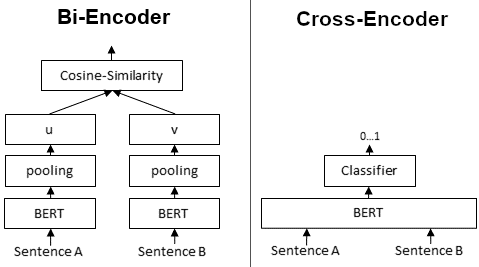

<br>

In [ ]:
# Re-ranking is now handled by LangChain's ContextualCompressionRetriever (see STEP 3.5).
# The cells below demonstrate standalone cross-encoder scoring for transparency.
print("Re-ranking via LangChain ContextualCompressionRetriever is configured in STEP 3.5.")
print("The cells below show raw cross-encoder scoring for educational purposes.")


In [ ]:
from sentence_transformers import CrossEncoder as _CE
# Cross-encoder already available as cross_encoder_hf from STEP 3.5
print("Cross-encoder model loaded via HuggingFaceCrossEncoder in STEP 3.5")


In [ ]:
# Initialise the cross encoder model
from sentence_transformers import CrossEncoder

cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

In [ ]:
# Test the cross encoder model

scores = cross_encoder.predict([['What are the Policy guidelines for Loss of Use or Paralysis', 'If a Member sustains an injury, and as a result of such injury, one or more of the covered losses listed below are incurred, The Principal will pay the following percentages of the Members Scheduled Benefit (or approved amount, if applicable) in force, provided all Benefit Qualifications as described in Article 2 are met.'],
                                ['What are the Policy guidelines for Loss of Use or Paralysis', 'If death occurs while Coverage During Disability is in force, The Principal will pay the Members beneficiary the Member Life Insurance benefit amount that would have been paid had the Member remained insured under the Schedule of Insurance in force on the date Total Disability began.']])
                                

In [ ]:
scores

In [ ]:
# Input (query, response) pairs for each of the top 20 responses received from the semantic search to the cross encoder
# Generate the cross_encoder scores for these pairs
#results_df = final_chunks.copy()
cross_inputs = [[query, response] for response in results_df['Documents']]
cross_rerank_scores = cross_encoder.predict(cross_inputs)

In [ ]:
cross_rerank_scores

In [ ]:
# Store the rerank_scores in results_df

results_df['Reranked_scores'] = cross_rerank_scores 

In [ ]:
results_df

In [ ]:
# Return the top 3 results from semantic search

top_3_semantic = results_df.sort_values(by='Distances')
top_3_semantic[:3]

In [ ]:
# Return the top 3 results after reranking

top_3_rerank = results_df.sort_values(by='Reranked_scores', ascending=False)
top_3_rerank[:3]

In [ ]:
top_3_RAG = top_3_rerank[["Documents", "Metadatas"]][:3]

In [ ]:
top_3_RAG

## 5. Retrieval Augmented Generation

Now that we have the final top search results, we can pass it to an GPT 3.5 along with the user query and a well-engineered prompt, to generate a direct answer to the query along with citations, rather than returning whole pages/chunks.

In [ ]:
import os
from groq import Groq

# Load API key from environment variable (more secure than hardcoding)
groq_api_key = os.environ.get("GROQ_API_KEY", "")
groq_client = Groq(api_key=groq_api_key)

print("✓ Groq client initialised")


In [ ]:
def retrieve_context(query: str, n_results: int = 5) -> dict:
    """Retrieve relevant chunks from FAISS vector store."""
    retriever_n = vectorstore.as_retriever(search_kwargs={"k": n_results})
    docs = retriever_n.invoke(query)
    return {
        "documents": [d.page_content for d in docs],
        "metadatas": [d.metadata for d in docs],
        "distances": [0.0] * len(docs),
        "ids":       [d.metadata.get("Chunk_ID", "") for d in docs],
    }


def format_context_for_prompt(retrieved_results: dict) -> str:
    parts = []
    for i, (doc, metadata, distance) in enumerate(zip(
        retrieved_results["documents"],
        retrieved_results["metadatas"],
        retrieved_results["distances"],
    ), 1):
        parts.append(
            f"""[Document {i}]
Policy: {metadata.get("Policy_Name", "Unknown")}
Page: {metadata.get("Page_No", "Unknown")}
Chunk ID: {metadata.get("Chunk_ID", "Unknown")}

Content:
{doc}

---"""
        )
    return "\n".join(parts)


def create_rag_prompt(query: str, context: str) -> list:
    system_prompt = """You are an expert insurance policy assistant.
Guidelines:
1. Answer directly and concisely using ONLY the provided context.
2. Cite policy names and page numbers.
3. If context is insufficient, say so clearly.
4. Use bullet points for multiple points.
5. End with citations: [Policy Name, Page X]"""

    return [
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": f"CONTEXT:\n{context}\n\nQUESTION:\n{query}"},
    ]


def generate_response_with_groq(messages, model="llama-3.3-70b-versatile", temperature=0.3, max_tokens=1024):
    try:
        response = groq_client.chat.completions.create(
            model=model, messages=messages,
            temperature=temperature, max_tokens=max_tokens,
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Error: {e}"


def rag_pipeline(query: str, n_results: int = 5, model: str = "llama-3.3-70b-versatile", verbose: bool = True):
    if verbose:
        print(f"Query: {query}\n{'='*100}")
    retrieved = retrieve_context(query, n_results)
    context   = format_context_for_prompt(retrieved)
    messages  = create_rag_prompt(query, context)
    response  = generate_response_with_groq(messages, model=model)
    if verbose:
        print(f"\nRESPONSE:\n{response}\n{'='*100}")
        print("SOURCES:")
        for m in retrieved["metadatas"]:
            print(f"  {m.get('Policy_Name')} — Page {m.get('Page_No')} (Chunk: {m.get('Chunk_ID')})")
    return {"query": query, "response": response, "metadata": retrieved["metadatas"]}

print("✓ RAG pipeline functions created (FAISS-backed)")


In [ ]:
def interactive_rag_chat(model: str = "llama-3.3-70b-versatile"):
    """Interactive CLI chat loop using FAISS-backed RAG pipeline."""
    print("=" * 100)
    print("INSURANCE POLICY ASSISTANT")
    print("=" * 100)
    print("Ask questions about your insurance policy. Type \'quit\' to exit.\n")

    history = []
    while True:
        query = input("\nYou: ").strip()
        if query.lower() in ("quit", "exit", "q"):
            print("\nThank you for using the Insurance Policy Assistant!")
            break
        if not query:
            continue
        result = rag_pipeline(query=query, verbose=False)
        print(f"\nAssistant:\n{result['response']}")
        history.append({"query": query, "response": result["response"]})
    return history


def ask_insurance_question(query: str, model: str = "llama-3.3-70b-versatile"):
    return rag_pipeline(query=query, model=model, verbose=True)

print("✓ Interactive RAG chat ready (FAISS-backed, no collection arg needed)")


In [ ]:
# Test with sample queries
test_queries = [
    "What is covered under this insurance policy?",
    "What are the exclusions in this policy?",
    "What are the Policy guidelines for Loss of Use or Paralysis?",
    "How do I file a claim?",
    "What is the premium amount and payment schedule?",
    "What happens if I miss a premium payment?"
]

print(" TESTING RAG SYSTEM")
print("="*100)

# Test basic RAG
for query in test_queries[:3]:  # Test first 2 queries
    result = ask_insurance_question(query)
    print("\n" + "="*100 + "\n")